# Importation des Bibliothèques

In [ ]:
import pandas as pd
import matplotlib as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt


# Lecture des Données

In [ ]:
df=pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv") # read a csv dataset

# Exploration et Nettoyage des Données

In [ ]:
df.shape # return how much row and columns are there

(2111, 17)

In [ ]:
df.head() #  return the first '5' rows

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.tail() #  return the last '5' rows

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [ ]:
df.info() # prints a concise summary of a DataFrame to the console

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [ ]:
df.isna().sum()
## Missing Values✅
# detect missing or null values  (we can use  df.isnull().sum() )
# data set is clear no missing values otherwise we have to apply .dropna()/.fillna()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:
r=df["NObeyesdad"]              # calculating the frequency distribution of unique values
r.value_counts(normalize=True) # classes are roughly equally re# normilize=False if you want to see count rather then proportion

## Distribution of classes✅
# classes are roughly equally represented in the dataset.
# normilize=False if you want to see count rather then proportion

,proportion
NObeyesdad,
Obesity_Type_I,0.166272
Obesity_Type_III,0.153482
Obesity_Type_II,0.140692
Overweight_Level_I,0.137376
Overweight_Level_II,0.137376
Normal_Weight,0.135955
Insufficient_Weight,0.128849


In [ ]:
data=df
binary_classification_columns=["family_history_with_overweight","FAVC","SMOKE","SCC"]
for col in binary_classification_columns:
  data[col]=data[col].map({"yes":1,"no":0})
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

## String problem✅
# Converting binary categorical columns (yes/no) to boolean (1/0)
# because ML models cannot work with string values

In [ ]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
le=LabelEncoder()
data["CAEC"]=le.fit_transform(df["CAEC"])
data["CALC"]=le.fit_transform(df["CALC"])
data["MTRANS"]=le.fit_transform(df["MTRANS"])
data["NObeyesdad"]=le.fit_transform(df["NObeyesdad"])

## non-binary categorical problem ✅
# Encoding non-binary categorical columns (MTRANS, CALC) using LabelEncoder
# which converts each unique category to a numeric value (e.g. 0,1,2,3...)
# since these columns have more than 2 categories, simple yes/no mapping is not applicable


In [ ]:
data[["Age","Height","Weight","FCVC","NCP","CH2O","FAF","TUE"]].describe()

 # check for anything unrealistic numerical columns like Age, Weight, Height ...ect
 # everything seems natural and ok

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
data.corr()
## Correlation analysis✅
# Correlation analysis revealed moderate correlations between certain features:
# - Weight and family_history_with_overweight: 0.496820
# - Height and Weight: 0.463136
# The target variable NObeyesdad is most correlated with Weight,
# family_history_with_overweight, CAEC and FAF
# These correlations are moderate (under 0.5) so no features were dropped,
# as removing them could reduce model performance

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
Gender,1.000000,0.048394,0.618466,0.161668,0.102512,0.064934,-0.274505,0.067600,0.091543,0.044698,0.107930,-0.102633,0.189607,0.017269,0.007616,-0.137537,0.024908
Age,0.048394,1.000000,-0.025958,0.202560,0.205725,0.063902,0.016291,-0.043944,0.083739,0.091987,-0.045304,-0.116283,-0.144938,-0.296931,-0.044487,-0.601945,0.236170
Height,0.618466,-0.025958,1.000000,0.463136,0.247684,0.178364,-0.038121,0.243672,0.048818,0.055499,0.213376,-0.133753,0.294709,0.051912,-0.129732,-0.073609,0.038986
Weight,0.161668,0.202560,0.463136,1.000000,0.496820,0.272300,0.216125,0.107469,0.287493,0.025746,0.200575,-0.201906,-0.051436,-0.071561,-0.206677,0.004610,0.387643
family_history_with_overweight,0.102512,0.205725,0.247684,0.496820,1.000000,0.208036,0.040372,0.071370,0.169787,0.017385,0.147437,-0.185422,-0.056673,0.022943,0.036676,-0.101540,0.313667
FAVC,0.064934,0.063902,0.178364,0.272300,0.208036,1.000000,-0.027283,-0.007000,0.150068,-0.050660,0.009719,-0.190658,-0.107995,0.068417,-0.089520,-0.069800,0.044582
FCVC,-0.274505,0.016291,-0.038121,0.216125,0.040372,-0.027283,1.000000,0.042216,-0.054670,0.014320,0.068461,0.071852,0.019939,-0.101135,-0.060781,0.064743,0.018522
NCP,0.067600,-0.043944,0.243672,0.107469,0.071370,-0.007000,0.042216,1.000000,-0.097801,0.007811,0.057088,-0.015624,0.129504,0.036326,-0.071747,-0.053858,-0.092616
CAEC,0.091543,0.083739,0.048818,0.287493,0.169787,0.150068,-0.054670,-0.097801,1.000000,-0.055282,0.144995,-0.109179,-0.030110,-0.048567,-0.047540,-0.048535,0.327295
SMOKE,0.044698,0.091987,0.055499,0.025746,0.017385,-0.050660,0.014320,0.007811,-0.055282,1.000000,-0.031995,0.047731,0.011216,0.017613,-0.082471,-0.010702,-0.023256


In [ ]:
data.memory_usage(deep=True)

## Memory usage problem✅
# Memory usage analysis shows all columns consume 16888 bytes each
# which corresponds to the default float64/int64 data types used by pandas
# by converting float64 to float32 and int64 to int32 we can reduce
# memory consumption by approximately 50% per column
# this is handled by the optimize_memory(df) function in src/data_processing.py

,0
Index,132
Gender,16888
Age,16888
Height,16888
Weight,16888
family_history_with_overweight,16888
FAVC,16888
FCVC,16888
NCP,16888
CAEC,16888


In [ ]:
## optimization function for Memory usage problem✅
def optimize_memory(data):
    for col in data.columns:
        if data[col].dtype == "float64":
            data[col] = data[col].astype("float32")
        elif data[col].dtype == "int64":
            data[col] = data[col].astype("int32")
    return data

In [ ]:
data=optimize_memory(data)
data.memory_usage(deep=True)
## problem is fixed ✅
# After applying optimize_memory(), all columns were reduced from 16888 to 8444 bytes
# confirming exactly 50% memory reduction across all features
# this improvement is achieved by downcasting float64 to float32 and int64 to int32
# which is sufficient precision for machine learning tasks

,0
Index,132
Gender,8444
Age,8444
Height,8444
Weight,8444
family_history_with_overweight,8444
FAVC,8444
FCVC,8444
NCP,8444
CAEC,8444


# Bonus

# Create a column that contain BMI Metric

In [ ]:
data["BmiMetric"]=data["Weight"]/(data["Height"])**2   # BMI metric formula

In [ ]:
data.to_csv('processed_data.csv', index=False)

In [ ]:
from google.colab import files
# Save your processed DataFrame to CSV
data.to_csv('processed_data.csv', index=False)
# Download to local machine
files.download('processed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BmiMetric
0,0,21.0,1.62,64.000000,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1,24.386528
1,0,21.0,1.52,56.000000,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1,24.238228
2,1,23.0,1.80,77.000000,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1,23.765434
3,1,27.0,1.80,87.000000,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5,26.851854
4,1,22.0,1.78,89.800003,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6,28.342384


In [ ]:
data["BmiMetric"].sort_values()

,BmiMetric
627,12.998685
302,13.291588
698,14.160576
563,14.253877
330,15.432100
...,...
1910,49.378120
344,49.472389
2078,49.699917
1898,50.014023


In [ ]:
data.corr()


# BMI correlation analysis confirms its medical validity:
# - BMI and NObeyesdad: 0.429686 (moderate) expected since obesity is partly defined by BMI
# - BMI and family_history_with_overweight: 0.483508 (moderate) confirming genetic influence on BMI
# - BMI and Weight: 0.934806 (very strong) which is expected since weight is the numerator in the BMI formula
# BMI will be kept as a feature as it adds medical value to the model

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BmiMetric
Gender,1.000000,0.048394,0.618466,0.161668,0.102512,0.064934,-0.274505,0.067600,0.091543,0.044698,0.107930,-0.102633,0.189607,0.017269,0.007616,-0.137537,0.024908,-0.053035
Age,0.048394,1.000000,-0.025958,0.202560,0.205725,0.063902,0.016291,-0.043944,0.083739,0.091987,-0.045304,-0.116283,-0.144938,-0.296931,-0.044487,-0.601945,0.236170,0.244163
Height,0.618466,-0.025958,1.000000,0.463136,0.247684,0.178364,-0.038121,0.243672,0.048818,0.055499,0.213376,-0.133753,0.294709,0.051912,-0.129732,-0.073609,0.038986,0.131785
Weight,0.161668,0.202560,0.463136,1.000000,0.496820,0.272300,0.216125,0.107469,0.287493,0.025746,0.200575,-0.201906,-0.051436,-0.071561,-0.206677,0.004610,0.387643,0.934806
family_history_with_overweight,0.102512,0.205725,0.247684,0.496820,1.000000,0.208036,0.040372,0.071370,0.169787,0.017385,0.147437,-0.185422,-0.056673,0.022943,0.036676,-0.101540,0.313667,0.483508
FAVC,0.064934,0.063902,0.178364,0.272300,0.208036,1.000000,-0.027283,-0.007000,0.150068,-0.050660,0.009719,-0.190658,-0.107995,0.068417,-0.089520,-0.069800,0.044582,0.246097
FCVC,-0.274505,0.016291,-0.038121,0.216125,0.040372,-0.027283,1.000000,0.042216,-0.054670,0.014320,0.068461,0.071852,0.019939,-0.101135,-0.060781,0.064743,0.018522,0.263651
NCP,0.067600,-0.043944,0.243672,0.107469,0.071370,-0.007000,0.042216,1.000000,-0.097801,0.007811,0.057088,-0.015624,0.129504,0.036326,-0.071747,-0.053858,-0.092616,0.039969
CAEC,0.091543,0.083739,0.048818,0.287493,0.169787,0.150068,-0.054670,-0.097801,1.000000,-0.055282,0.144995,-0.109179,-0.030110,-0.048567,-0.047540,-0.048535,0.327295,0.313278
SMOKE,0.044698,0.091987,0.055499,0.025746,0.017385,-0.050660,0.014320,0.007811,-0.055282,1.000000,-0.031995,0.047731,0.011216,0.017613,-0.082471,-0.010702,-0.023256,-0.000819


In [ ]:
data.isna()

# Correlation Heat Map


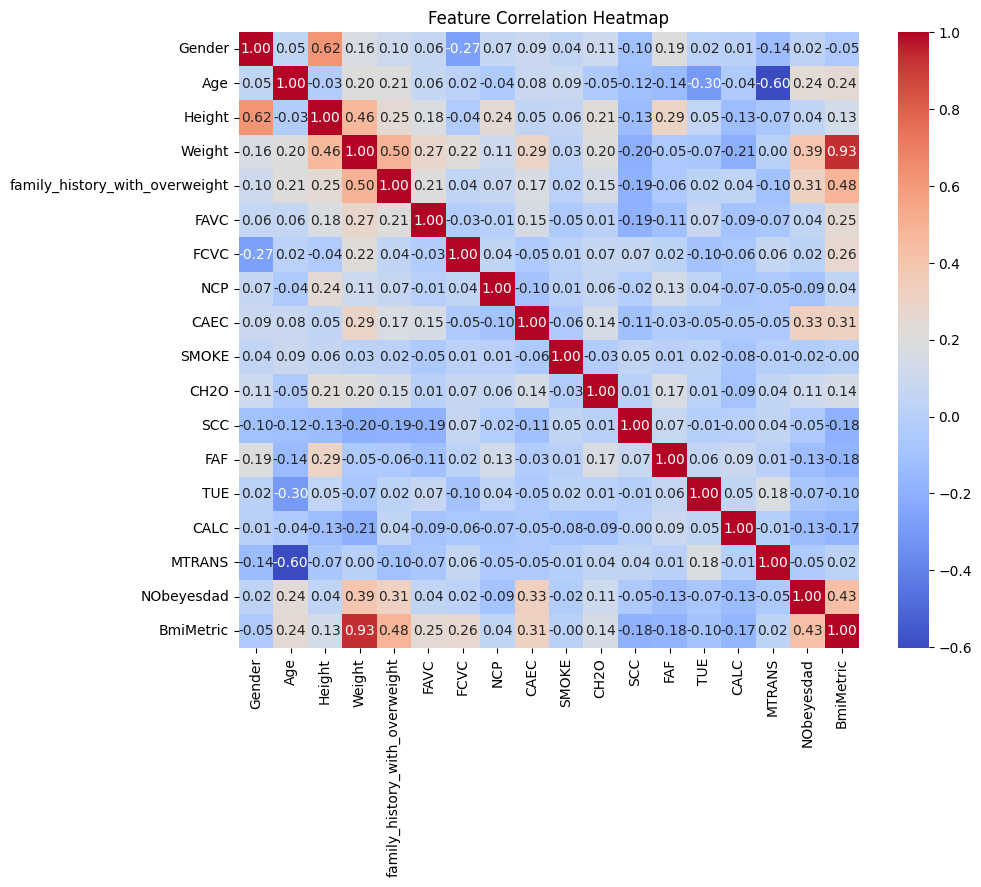

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()